In [1]:
import pandas as pd
import numpy as np
# Load dataset
df = pd.read_csv(r"C:\Users\thamb\Downloads\influencer_campaign_data.csv")

print("Shape:", df.shape)
df.head()

Shape: (30150, 22)


,campaign_id,influencer_id,influencer_name,platform,influencer_category,followers_count,campaign_type,start_date,end_date,campaign_duration_days,...,impressions,estimated_reach,likes,comments,shares,clicks,conversions,product_sales,campaign_cost,revenue_generated
0,CMP018841,INF01143,Creator_1143,TikTok,Tech,515305.0,Brand Awareness,2023-08-15,2023-08-27,12,...,372062,313659,5428,858,408.0,16742,1553,1342,300200.0,5193097.84
1,CMP025412,INF00348,Creator_348,TikTok,Lifestyle,1518.0,Tutorial/How-to,2024-08-27,2024-09-01,5,...,2970,1233,134,25,17.0,92,10,10,2110.0,10711.38
2,CMP024838,INF00512,Creator_512,Twitter/X,Travel,47095.0,Sales Promotion,2023-05-19,2023-05-24,5,...,16068,11861,521,60,6.0,362,39,37,9850.0,208842.30
3,CMP008164,INF01132,Creator_1132,Twitter/X,Gaming,96273.0,Tutorial/How-to,2024-05-25,2024-05-29,4,...,23424,16701,863,82,155.0,901,79,83,59120.0,212948.80
4,CMP027576,INF00006,Creator_6,Instagram,Gaming,4207.0,Brand Awareness,2024-10-31,2024-11-10,10,...,2604,1378,117,9,7.0,154,16,17,4240.0,28974.65


In [2]:
df.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30150 entries, 0 to 30149
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   campaign_id             30150 non-null  object 
 1   influencer_id           30150 non-null  object 
 2   influencer_name         30150 non-null  object 
 3   platform                30150 non-null  object 
 4   influencer_category     30150 non-null  object 
 5   followers_count         29546 non-null  float64
 6   campaign_type           30150 non-null  object 
 7   start_date              30150 non-null  object 
 8   end_date                30150 non-null  object 
 9   campaign_duration_days  30150 non-null  int64  
 10  audience_age_group      29549 non-null  object 
 11  region                  29546 non-null  object 
 12  impressions             30150 non-null  int64  
 13  estimated_reach         30150 non-null  int64  
 14  likes                   30150 non-null

In [3]:
df.describe()

,followers_count,campaign_duration_days,impressions,estimated_reach,likes,comments,shares,clicks,conversions,product_sales,campaign_cost,revenue_generated
count,2.954600e+04,30150.000000,3.015000e+04,3.015000e+04,30150.000000,30150.000000,29547.000000,30150.000000,30150.000000,30150.000000,2.954900e+04,2.954800e+04
mean,1.118507e+06,9.004610,8.885289e+05,4.928335e+05,8546.284411,1058.257877,755.101432,31154.676949,2184.334063,2292.195589,3.287957e+05,4.890441e+06
std,2.079951e+06,5.638102,1.896110e+06,1.018085e+06,16729.070381,2134.433026,1797.694851,73393.200641,5683.818264,6008.825183,5.037684e+05,1.646400e+07
min,1.044000e+03,1.000000,1.800000e+02,1.450000e+02,6.000000,1.000000,0.000000,3.000000,0.000000,0.000000,1.530000e+03,0.000000e+00
25%,8.969000e+03,5.000000,6.381250e+03,3.637000e+03,239.250000,29.000000,15.000000,202.000000,13.000000,13.000000,5.970000e+03,2.129316e+04
50%,1.049570e+05,8.000000,7.126250e+04,4.152100e+04,1581.000000,193.000000,101.000000,2206.500000,136.000000,142.000000,5.707000e+04,2.208499e+05
75%,1.052457e+06,12.000000,7.391118e+05,4.230300e+05,8675.500000,1048.000000,616.000000,23071.750000,1423.750000,1498.000000,5.934900e+05,2.454443e+06
max,9.974031e+06,45.000000,1.803205e+07,7.637435e+06,182035.000000,27853.000000,26495.000000,942941.000000,99526.000000,99589.000000,2.582520e+06,3.975913e+08


In [4]:
# Check missing values and duplicates


print("Missing values per column:\n", df.isna().sum()[df.isna().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())





Missing values per column:
 followers_count       604
audience_age_group    601
region                604
shares                603
campaign_cost         601
revenue_generated     602
dtype: int64

Duplicate rows: 150


In [5]:
# Remove duplicates
print("before dup:",df.shape)

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)



before dup: (30150, 22)
Shape after removing duplicates: (30000, 22)


In [6]:
# ---------------------------------------------------
# Convert date columns
print("BEFORE conversion:")
print(df[['start_date', 'end_date']].dtypes)

df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date'] = pd.to_datetime(df['end_date'])
print("AFTER conversion:")
print(df[['start_date', 'end_date']].dtypes)


BEFORE conversion:
start_date    object
end_date      object
dtype: object
AFTER conversion:
start_date    datetime64[ns]
end_date      datetime64[ns]
dtype: object


In [7]:
# ---------------------------------------------------
# Handle missing values
# ---------------------------------------------------
# Numeric columns -> fill with median within same influencer_category
num_cols_median = ['followers_count', 'shares', 'campaign_cost', 'revenue_generated']
for col in num_cols_median:
    df[col] = df[col].fillna(df.groupby('influencer_category')[col].transform('median'))
    df[col] = df[col].fillna(df[col].median())  # fallback safety net

# Categorical columns -> fill with 'Unknown' / mode
df['region'] = df['region'].fillna('Unknown')
df['audience_age_group'] = df['audience_age_group'].fillna(df['audience_age_group'].mode()[0])

print("Remaining missing values:", df.isna().sum().sum())

Remaining missing values: 0


In [8]:
# ---------------------------------------------------
# Create Derived Features
# ---------------------------------------------------

# Engagement Rate = (Likes + Comments + Shares) / Reach
df['engagement_rate'] = (df['likes'] + df['comments'] + df['shares']) / df['estimated_reach']

# ROI = (Revenue - Cost) / Cost * 100
df['roi'] = (df['revenue_generated'] - df['campaign_cost']) / df['campaign_cost'] * 100

# Extra useful derived features
df['cost_per_engagement'] = df['campaign_cost'] / (df['likes'] + df['comments'] + df['shares'])
df['conversion_rate'] = df['conversions'] / df['clicks']
df['ctr'] = df['clicks'] / df['impressions']

def tier_from_followers(f):
    if f < 10_000: return 'Nano'
    elif f < 50_000: return 'Micro'
    elif f < 500_000: return 'Mid-tier'
    elif f < 1_000_000: return 'Macro'
    else: return 'Mega'

df['influencer_tier'] = df['followers_count'].apply(tier_from_followers)

# Guard against inf values from any zero-division edge cases
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(subset=['engagement_rate', 'roi', 'cost_per_engagement', 'conversion_rate'], inplace=True)

print("Final cleaned shape:", df.shape)
df[['engagement_rate', 'roi', 'cost_per_engagement', 'conversion_rate', 'influencer_tier']].head()

Final cleaned shape: (30000, 28)


,engagement_rate,roi,cost_per_engagement,conversion_rate,influencer_tier
0,0.021342,1629.879360,44.846131,0.092761,Macro
1,0.142741,407.648341,11.988636,0.108696,Nano
2,0.049490,2020.226396,16.780239,0.107735,Micro
3,0.065864,260.197564,53.745455,0.087680,Mid-tier
4,0.096517,583.364387,31.879699,0.103896,Nano


In [9]:
# ---------------------------------------------------
# Save cleaned data for next phases
# ---------------------------------------------------
df.to_csv('cleaned_data.csv', index=False)
print(df.head(5))

print("Saved cleaned_data.csv")

  campaign_id influencer_id influencer_name   platform influencer_category  \
0   CMP018841      INF01143    Creator_1143     TikTok                Tech   
1   CMP025412      INF00348     Creator_348     TikTok           Lifestyle   
2   CMP024838      INF00512     Creator_512  Twitter/X              Travel   
3   CMP008164      INF01132    Creator_1132  Twitter/X              Gaming   
4   CMP027576      INF00006       Creator_6  Instagram              Gaming   

   followers_count    campaign_type start_date   end_date  \
0         515305.0  Brand Awareness 2023-08-15 2023-08-27   
1           1518.0  Tutorial/How-to 2024-08-27 2024-09-01   
2          47095.0  Sales Promotion 2023-05-19 2023-05-24   
3          96273.0  Tutorial/How-to 2024-05-25 2024-05-29   
4           4207.0  Brand Awareness 2024-10-31 2024-11-10   

   campaign_duration_days  ... conversions product_sales  campaign_cost  \
0                      12  ...        1553          1342       300200.0   
1             

In [10]:
import pandas as pd

# Load cleaned data from Phase 1
df = pd.read_csv('cleaned_data.csv')

# ---------------------------------------------------
# Phase 2: KPI Design
# ---------------------------------------------------

kpis = {
    'Total Campaigns': df['campaign_id'].nunique(),
    'Total Reach': df['estimated_reach'].sum(),
    'Total Revenue (₹)': df['revenue_generated'].sum(),
    'Total Spend (₹)': df['campaign_cost'].sum(),
    'Average Engagement Rate (%)': df['engagement_rate'].mean() * 100,
    'Average ROI (%)': df['roi'].mean(),
    'Cost Per Engagement (₹)': df['cost_per_engagement'].mean(),
    'Conversion Rate (%)': df['conversion_rate'].mean() * 100,
}

kpi_df = pd.DataFrame(list(kpis.items()), columns=['KPI', 'Value'])
kpi_df['Value'] = kpi_df['Value'].round(2)
print(kpi_df.to_string(index=False))
kpi_df.to_csv('kpi_summary.csv', index=False)
kpi_df.head()


                        KPI        Value
            Total Campaigns 3.000000e+04
                Total Reach 1.476815e+10
          Total Revenue (₹) 1.440516e+11
            Total Spend (₹) 9.693549e+09
Average Engagement Rate (%) 5.660000e+00
            Average ROI (%) 1.170070e+03
    Cost Per Engagement (₹) 4.608000e+01
        Conversion Rate (%) 6.980000e+00


,KPI,Value
0,Total Campaigns,3.000000e+04
1,Total Reach,1.476815e+10
2,Total Revenue (₹),1.440516e+11
3,Total Spend (₹),9.693549e+09
4,Average Engagement Rate (%),5.660000e+00


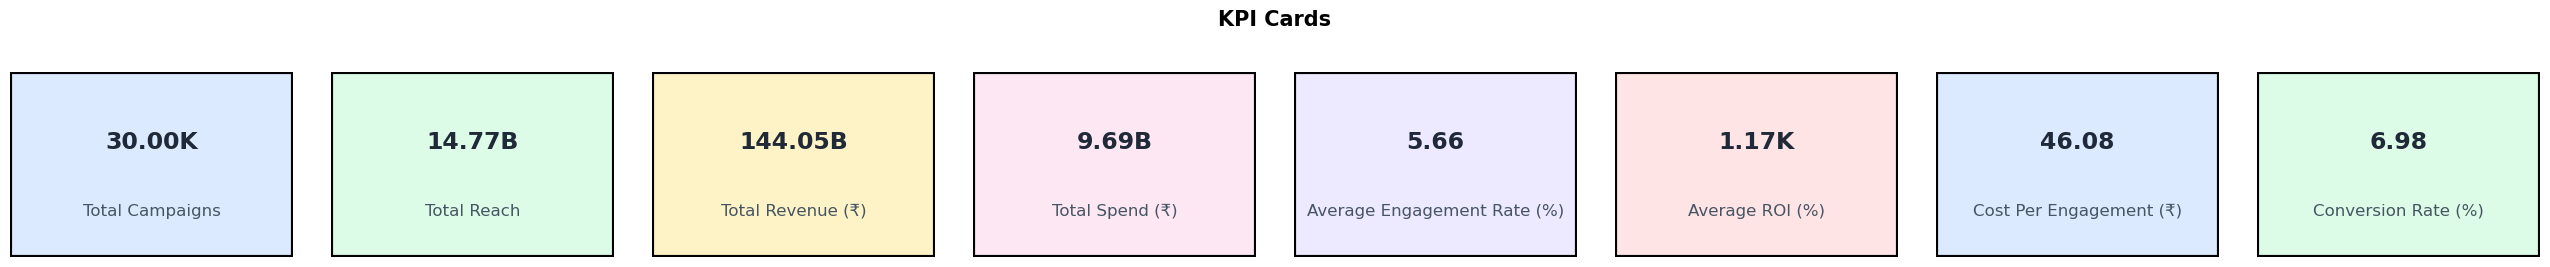

In [11]:
# Phase 3 (Analytics Investigation) 
import pandas as pd
import matplotlib.pyplot as plt

kpi_df = pd.read_csv('kpi_summary.csv')  

def format_big_number(val):
    """Convert large numbers into readable K/M/B/Cr format."""
    abs_val = abs(val)
    if abs_val >= 1e9:
        return f"{val/1e9:.2f}B"
    elif abs_val >= 1e7:
        return f"{val/1e7:.2f}Cr"
    elif abs_val >= 1e5:
        return f"{val/1e5:.2f}L"
    elif abs_val >= 1e3:
        return f"{val/1e3:.2f}K"
    else:
        return f"{val:.2f}"

# ---------------------------------------------------
# KPI Cards 
# ---------------------------------------------------
n = len(kpi_df)
fig, axes = plt.subplots(1, n, figsize=(3.2*n, 2.5))

if n == 1:
    axes = [axes]

card_colors = ['#DBEAFE', '#DCFCE7', '#FEF3C7', '#FCE7F3', '#EDE9FE', '#FFE4E6']

for i, (ax, row) in enumerate(zip(axes, kpi_df.itertuples())):
    value = row.Value
    kpi_name = row.KPI

    if abs(value) >= 1000:
        display_val = format_big_number(value)
    else:
        display_val = f"{value:,.2f}"

    ax.axis('off')

    color = card_colors[i % len(card_colors)]

    ax.add_patch(plt.Rectangle(
        (0, 0), 1, 1, transform=ax.transAxes,
        facecolor=color, edgecolor='black', linewidth=3
    ))

    ax.text(0.5, 0.62, display_val, ha='center', va='center',
            fontsize=17, fontweight='bold', color='#1f2937',
            transform=ax.transAxes)

    ax.text(0.5, 0.25, kpi_name, ha='center', va='center',
            fontsize=12, color='#465563',
            transform=ax.transAxes, wrap=True)

plt.suptitle('KPI Cards', fontweight='bold', fontsize=15, y=1.05)
plt.tight_layout()
plt.savefig('p3_kpi_cards.png', bbox_inches='tight', dpi=120)
plt.show()

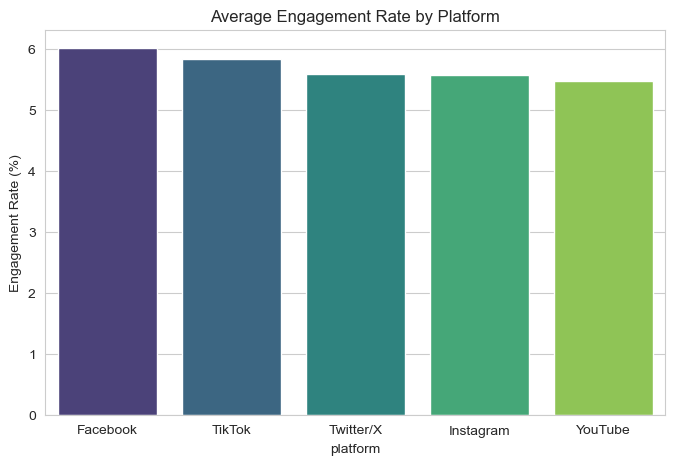

 correlation b/w campaign cost and ROI across all campaigns is : 0.026


In [31]:
# ---------------------------------------------------
# 1. Platform vs Engagement
# ---------------------------------------------------
import seaborn as sns

plt.figure(figsize=(8,5))
platform_er = df.groupby('platform')['engagement_rate'].mean().sort_values(ascending=False) * 100
sns.barplot(x=platform_er.index, y=platform_er.values, hue=platform_er.index, palette='viridis', legend=False)
plt.title('Average Engagement Rate by Platform')
plt.ylabel('Engagement Rate (%)')
plt.savefig('p3_platform_engagement.png', bbox_inches='tight', dpi=100)
plt.show()
print(" correlation b/w campaign cost and ROI across all campaigns is : 0.026")


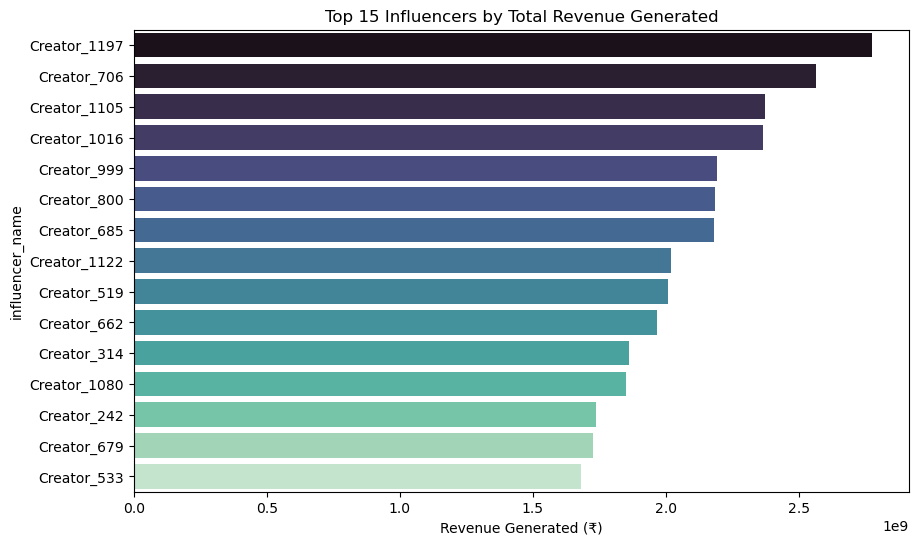

In [13]:
# ---------------------------------------------------
# 2. Influencer vs Revenue (Top 15)
# ---------------------------------------------------
plt.figure(figsize=(10,6))
top_inf = df.groupby('influencer_name')['revenue_generated'].sum().sort_values(ascending=False).head(15)
sns.barplot(x=top_inf.values, y=top_inf.index, hue=top_inf.index, palette='mako', legend=False)
plt.title('Top 15 Influencers by Total Revenue Generated')
plt.xlabel('Revenue Generated (₹)')
plt.savefig('p3_top_influencers_revenue.png', bbox_inches='tight', dpi=100)
plt.show()

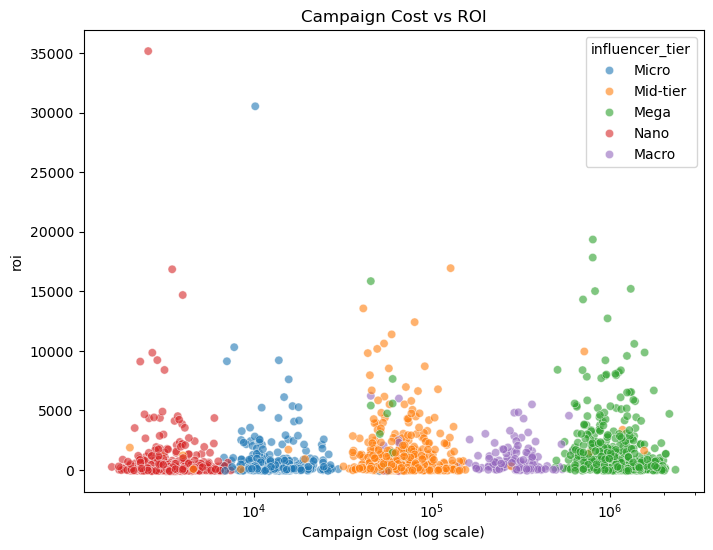

In [14]:
# ---------------------------------------------------
# 3. Campaign Cost vs ROI
# ---------------------------------------------------
plt.figure(figsize=(8,6))
sample = df.sample(2000, random_state=1)
sns.scatterplot(data=sample, x='campaign_cost', y='roi', hue='influencer_tier', alpha=0.6)
plt.title('Campaign Cost vs ROI')
plt.xscale('log')
plt.xlabel('Campaign Cost (log scale)')
plt.savefig('p3_cost_vs_roi.png', bbox_inches='tight', dpi=100)
plt.show()

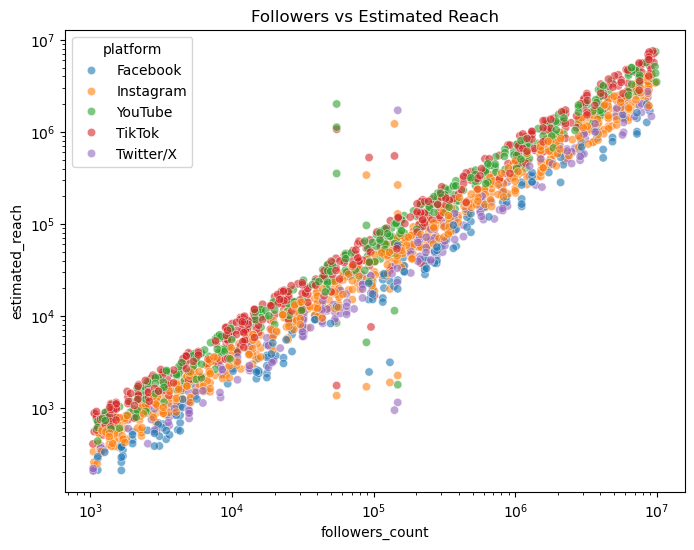

In [15]:
# ---------------------------------------------------
# 4. Followers vs Reach
# ---------------------------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(data=sample, x='followers_count', y='estimated_reach', hue='platform', alpha=0.6)
plt.title('Followers vs Estimated Reach')
plt.xscale('log'); plt.yscale('log')
plt.savefig('p3_followers_vs_reach.png', bbox_inches='tight', dpi=100)
plt.show()

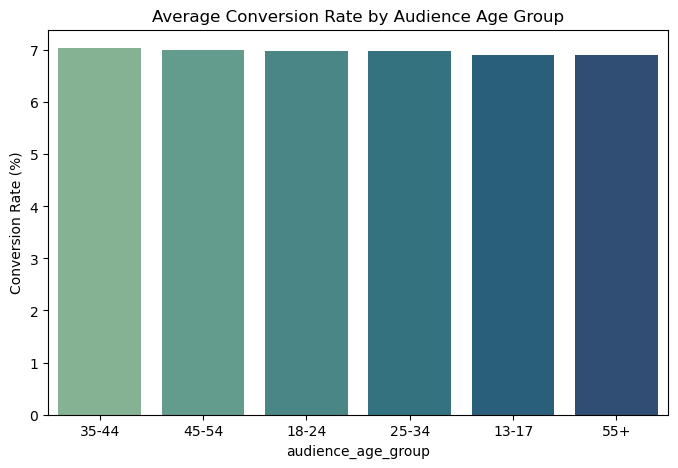

In [16]:
# ---------------------------------------------------
# 5. Audience Group vs Performance
# ---------------------------------------------------
plt.figure(figsize=(8,5))
aud_perf = df.groupby('audience_age_group')['conversion_rate'].mean().sort_values(ascending=False) * 100
sns.barplot(x=aud_perf.index, y=aud_perf.values, hue=aud_perf.index, palette='crest', legend=False)
plt.title('Average Conversion Rate by Audience Age Group')
plt.ylabel('Conversion Rate (%)')
plt.savefig('p3_audience_conversion.png', bbox_inches='tight', dpi=100)
plt.show()

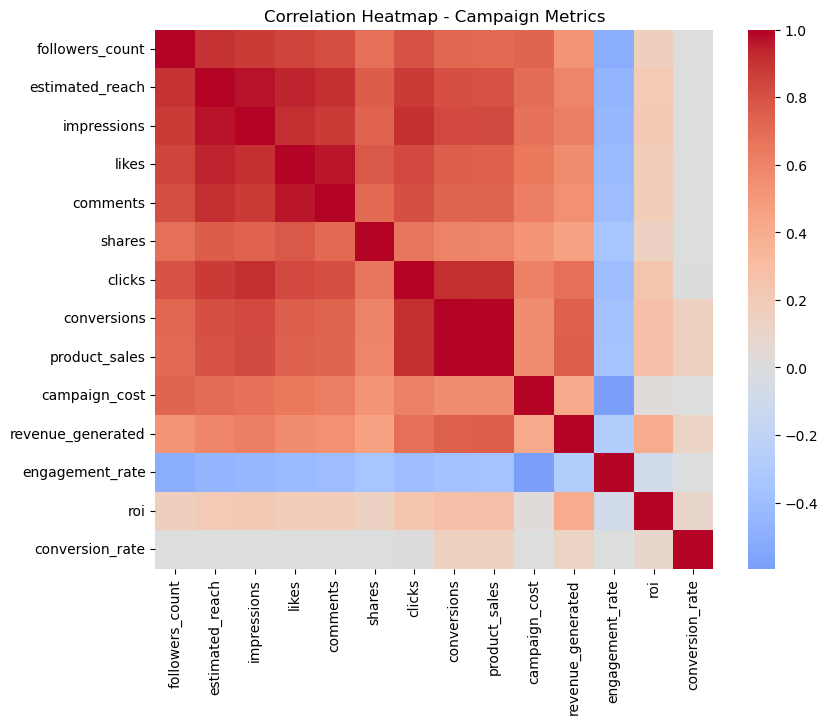

In [17]:
# ---------------------------------------------------
# 6. Correlation Heatmap
# ---------------------------------------------------
plt.figure(figsize=(9,7))
num_cols = ['followers_count','estimated_reach','impressions','likes','comments','shares',
            'clicks','conversions','product_sales','campaign_cost','revenue_generated',
            'engagement_rate','roi','conversion_rate']
corr = df[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Campaign Metrics')
plt.savefig('p3_heatmap.png', bbox_inches='tight', dpi=100)
plt.show()

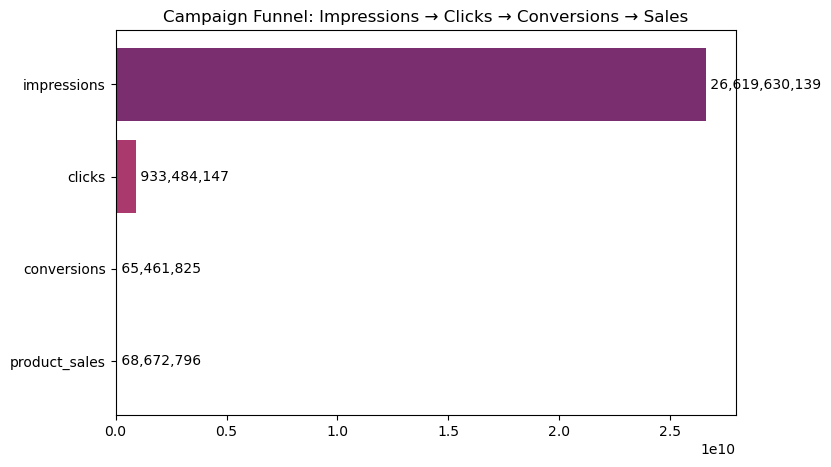

In [18]:
# ---------------------------------------------------
# 7. Funnel Analysis
# ---------------------------------------------------
funnel_stages = ['impressions', 'clicks', 'conversions', 'product_sales']
funnel_values = [df[s].sum() for s in funnel_stages]

plt.figure(figsize=(8,5))
plt.barh(funnel_stages[::-1], funnel_values[::-1], color=sns.color_palette('flare', len(funnel_stages)))
plt.title('Campaign Funnel: Impressions → Clicks → Conversions → Sales')
for i, v in enumerate(funnel_values[::-1]):
    plt.text(v, i, f' {v:,.0f}', va='center')
plt.savefig('p3_funnel.png', bbox_inches='tight', dpi=100)
plt.show()

In [19]:
import pandas as pd
import numpy as np

df = pd.read_csv('cleaned_data.csv')

# ---------------------------------------------------
# Q1: Which influencers drive strongest results?
# (Top revenue AND cost-efficient, not just high-spend)
# ---------------------------------------------------
influencer_summary = df.groupby('influencer_name').agg(
    total_revenue=('revenue_generated', 'sum'),
    total_cost=('campaign_cost', 'sum'),
    avg_roi=('roi', 'mean'),
    avg_cost_per_engagement=('cost_per_engagement', 'mean'),
    total_campaigns=('campaign_id', 'nunique')
).reset_index()

top_revenue = influencer_summary.sort_values('total_revenue', ascending=False).head(15)

# Cross-check: are they also cost-efficient? (below median cost per engagement)
median_cpe = influencer_summary['avg_cost_per_engagement'].median()
top_revenue['is_cost_efficient'] = top_revenue['avg_cost_per_engagement'] <= median_cpe

print("Top 15 Influencers by Revenue (with cost-efficiency flag):\n")
print(top_revenue[['influencer_name', 'total_revenue', 'avg_roi', 
                    'avg_cost_per_engagement', 'is_cost_efficient']].to_string(index=False))

print(f"\n-> {top_revenue['is_cost_efficient'].sum()} of the top 15 revenue drivers are ALSO cost-efficient.")
print(f"-> {15 - top_revenue['is_cost_efficient'].sum()} are high-spend but not necessarily efficient.")

Top 15 Influencers by Revenue (with cost-efficiency flag):

influencer_name  total_revenue      avg_roi  avg_cost_per_engagement  is_cost_efficient
   Creator_1197   2.776246e+09 31143.243746                12.198409               True
    Creator_706   2.566628e+09 11291.905557                13.912526               True
   Creator_1105   2.373763e+09  9146.394441                10.119207               True
   Creator_1016   2.366303e+09 19287.103291                32.021581               True
    Creator_999   2.192031e+09  8501.636615                21.695507               True
    Creator_800   2.185454e+09  9775.935835                20.175870               True
    Creator_685   2.181710e+09 11301.466585                37.339750              False
   Creator_1122   2.019773e+09  5290.755494                26.683214               True
    Creator_519   2.008494e+09 18578.301458                11.126815               True
    Creator_662   1.968119e+09 21756.077029                1

In [20]:
# ---------------------------------------------------
# Q2: Which platforms perform best?
# (Engagement rate weighed against cost per platform)
# ---------------------------------------------------
platform_summary = df.groupby('platform').agg(
    avg_engagement_rate=('engagement_rate', 'mean'),
    avg_cost=('campaign_cost', 'mean'),
    avg_roi=('roi', 'mean'),
    avg_cost_per_engagement=('cost_per_engagement', 'mean')
).sort_values('avg_engagement_rate', ascending=False)

platform_summary['avg_engagement_rate'] = platform_summary['avg_engagement_rate'] * 100

print("Platform Performance Summary:\n")
print(platform_summary.round(2).to_string())

best_engagement_platform = platform_summary['avg_engagement_rate'].idxmax()
best_efficiency_platform = platform_summary['avg_cost_per_engagement'].idxmin()

print(f"\n-> Highest engagement rate: {best_engagement_platform}")
print(f"-> Most cost-efficient (lowest cost per engagement): {best_efficiency_platform}")

if best_engagement_platform == best_efficiency_platform:
    print(f"-> {best_engagement_platform} wins on both counts — clear best platform.")
else:
    print(f"-> Tradeoff exists: {best_engagement_platform} engages best, but {best_efficiency_platform} is cheaper per engagement.")

Platform Performance Summary:

           avg_engagement_rate   avg_cost  avg_roi  avg_cost_per_engagement
platform                                                                   
Facebook                  6.02  182543.74   545.59                    70.17
TikTok                    5.85  274685.56  1864.14                    29.84
Twitter/X                 5.60  223963.25   783.80                    48.22
Instagram                 5.58  325326.10   910.96                    52.86
YouTube                   5.48  470850.75  1148.22                    45.57

-> Highest engagement rate: Facebook
-> Most cost-efficient (lowest cost per engagement): TikTok
-> Tradeoff exists: Facebook engages best, but TikTok is cheaper per engagement.


In [21]:
# ---------------------------------------------------
# Q3: Does higher spend increase ROI?
# (Correlation + binned trend check for diminishing returns)
# ---------------------------------------------------
correlation = df['campaign_cost'].corr(df['roi'])
print(f"Correlation between Campaign Cost and ROI: {correlation:.3f}")

# Bin spend into quartiles and check average ROI per bin
df['spend_bucket'] = pd.qcut(df['campaign_cost'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
spend_vs_roi = df.groupby('spend_bucket', observed=True)['roi'].mean()

print("\nAverage ROI by Spend Bucket:")
print(spend_vs_roi.round(2).to_string())

# Check if ROI trend is increasing, flat, or decreasing across buckets
roi_values = spend_vs_roi.values
if roi_values[-1] > roi_values[0]:
    trend = "ROI generally INCREASES with spend"
elif roi_values[-1] < roi_values[0]:
    trend = "ROI generally DECREASES at higher spend (diminishing returns)"
else:
    trend = "No clear directional trend"

print(f"\n-> Correlation is {'weak/near-zero' if abs(correlation) < 0.1 else 'moderate' if abs(correlation) < 0.4 else 'strong'} ({correlation:.3f})")
print(f"-> {trend}")

Correlation between Campaign Cost and ROI: 0.026

Average ROI by Spend Bucket:
spend_bucket
Very Low      672.18
Low           636.42
Medium       1938.83
High         1210.34
Very High    1392.52

-> Correlation is weak/near-zero (0.026)
-> ROI generally INCREASES with spend


In [22]:
#Phase 4: Influencer Segmentation 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cleaned_data.csv')
sns.set_style('whitegrid')

# ---------------------------------------------------
# Aggregate to influencer level (one influencer may run multiple campaigns)
# ---------------------------------------------------
inf_level = df.groupby('influencer_name').agg(
    followers_count=('followers_count', 'first'),
    influencer_tier=('influencer_tier', 'first'),
    total_campaigns=('campaign_id', 'nunique'),
    avg_engagement_rate=('engagement_rate', 'mean'),
    avg_roi=('roi', 'mean'),
    avg_cost_per_engagement=('cost_per_engagement', 'mean'),
    total_revenue=('revenue_generated', 'sum'),
    total_cost=('campaign_cost', 'sum')
).reset_index()

print("Influencer-level summary:")
inf_level.head()

Influencer-level summary:


,influencer_name,followers_count,influencer_tier,total_campaigns,avg_engagement_rate,avg_roi,avg_cost_per_engagement,total_revenue,total_cost
0,Creator_1,31489.0,Micro,30,0.080799,616.652287,19.226832,2141159.46,342690.0
1,Creator_10,679658.0,Macro,24,0.033654,1287.819235,45.979521,97146083.18,6941840.0
2,Creator_100,2701.0,Nano,20,0.079356,345.595371,53.539551,229917.45,53200.0
3,Creator_1000,60817.0,Mid-tier,24,0.050124,37.851306,90.902377,2362942.35,1735510.0
4,Creator_1001,5502.0,Nano,22,0.086386,1268.771465,24.024625,1657797.97,119620.0


In [23]:
# ---------------------------------------------------
# Create segmentation categories using quartile thresholds
# ---------------------------------------------------
roi_75 = inf_level['avg_roi'].quantile(0.75)
er_75 = inf_level['avg_engagement_rate'].quantile(0.75)
cpe_25 = inf_level['avg_cost_per_engagement'].quantile(0.25)

def classify(row):
    tags = []
    if row['avg_roi'] >= roi_75:
        tags.append('High ROI')
    if row['avg_engagement_rate'] >= er_75:
        tags.append('High Engagement')
    if row['avg_cost_per_engagement'] <= cpe_25:
        tags.append('Cost Efficient')
    if row['influencer_tier'] in ['Nano', 'Micro']:
        tags.append('Micro Influencer')
    elif row['influencer_tier'] == 'Mega':
        tags.append('Mega Influencer')
    return ', '.join(tags) if tags else 'Standard'

inf_level['segment_tags'] = inf_level.apply(classify, axis=1)

print("Segment distribution (top combinations):")
print(inf_level['segment_tags'].value_counts().head(10))

Segment distribution (top combinations):
segment_tags
Standard                                             210
High Engagement, Micro Influencer                    207
Mega Influencer                                      168
Micro Influencer                                     134
High ROI, Mega Influencer                             95
Cost Efficient                                        73
High ROI, Cost Efficient                              54
Cost Efficient, Micro Influencer                      53
High ROI                                              45
High Engagement, Cost Efficient, Micro Influencer     44
Name: count, dtype: int64


In [24]:
# ---------------------------------------------------
# Analyze differences among groups (by influencer_tier)
# ---------------------------------------------------
tier_order = ['Nano', 'Micro', 'Mid-tier', 'Macro', 'Mega']

tier_compare = inf_level.groupby('influencer_tier')[
    ['avg_engagement_rate', 'avg_roi', 'avg_cost_per_engagement', 'total_revenue']
].mean().reindex(tier_order)

tier_compare['avg_engagement_rate'] = tier_compare['avg_engagement_rate'] * 100

print("Average metrics by Influencer Tier:")
print(tier_compare.round(2).to_string())

Average metrics by Influencer Tier:
                 avg_engagement_rate  avg_roi  avg_cost_per_engagement  total_revenue
influencer_tier                                                                      
Nano                            9.67   598.96                    53.94   6.123303e+05
Micro                           7.38   680.72                    30.32   2.832120e+06
Mid-tier                        4.78  1130.91                    33.64   3.159953e+07
Macro                           3.18   935.31                    40.12   7.018739e+07
Mega                            1.90  2210.58                    62.26   4.234521e+08


In [25]:
# ---------------------------------------------------
# Analyze differences among specific segment categories
# ---------------------------------------------------
segment_groups = {
    'High ROI Influencers': inf_level[inf_level['avg_roi'] >= roi_75],
    'Micro Influencers': inf_level[inf_level['influencer_tier'].isin(['Nano', 'Micro'])],
    'Mega Influencers': inf_level[inf_level['influencer_tier'] == 'Mega'],
    'High Engagement Creators': inf_level[inf_level['avg_engagement_rate'] >= er_75],
    'Cost Efficient Influencers': inf_level[inf_level['avg_cost_per_engagement'] <= cpe_25],
}

summary_rows = []
for name, group in segment_groups.items():
    summary_rows.append({
        'Segment': name,
        'Count': len(group),
        'Avg Engagement Rate (%)': group['avg_engagement_rate'].mean() * 100,
        'Avg ROI (%)': group['avg_roi'].mean(),
        'Avg Cost Per Engagement (₹)': group['avg_cost_per_engagement'].mean(),
        'Avg Total Revenue (₹)': group['total_revenue'].mean(),
    })

segment_summary = pd.DataFrame(summary_rows).round(2)
print("Segment-wise comparison:")
print(segment_summary.to_string(index=False))

Segment-wise comparison:
                   Segment  Count  Avg Engagement Rate (%)  Avg ROI (%)  Avg Cost Per Engagement (₹)  Avg Total Revenue (₹)
      High ROI Influencers    300                     4.34      3449.82                        31.31           376925166.15
         Micro Influencers    509                     8.78       630.77                        44.75             1475824.25
          Mega Influencers    302                     1.90      2210.58                        62.26           423452061.66
  High Engagement Creators    300                     9.76       601.94                        54.18              614185.66
Cost Efficient Influencers    300                     6.08      2089.35                        14.56           144933553.37


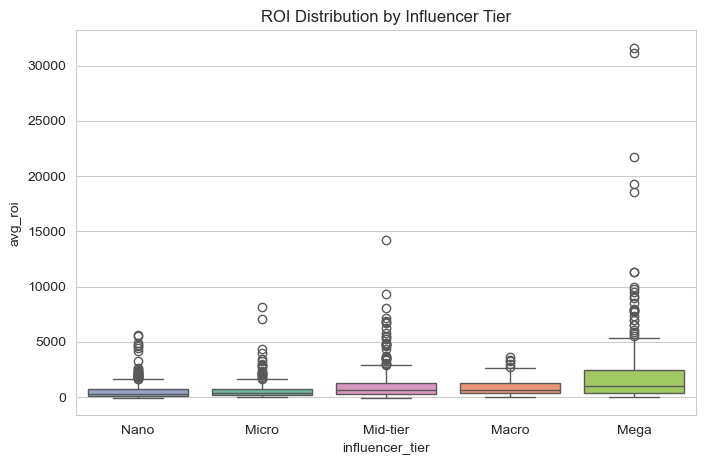

In [26]:
# ---------------------------------------------------
# Visualization 1: ROI distribution by tier
# ---------------------------------------------------
plt.figure(figsize=(8, 5))
sns.boxplot(data=inf_level, x='influencer_tier', y='avg_roi', order=tier_order,
            hue='influencer_tier', palette='Set2', legend=False)
plt.title('ROI Distribution by Influencer Tier')
plt.savefig('p4_roi_by_tier.png', bbox_inches='tight', dpi=100)
plt.show()

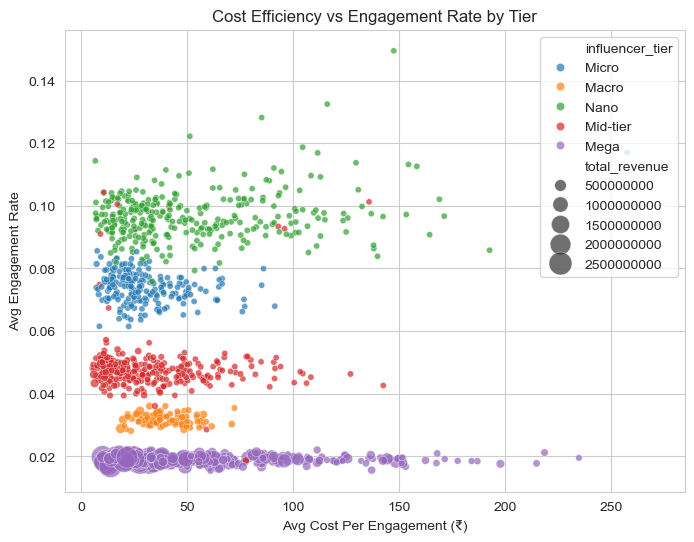

In [27]:
# ---------------------------------------------------
# Visualization 2: Cost efficiency vs engagement rate
# ---------------------------------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(data=inf_level, x='avg_cost_per_engagement', y='avg_engagement_rate',
                 hue='influencer_tier', size='total_revenue', sizes=(20, 300), alpha=0.7)
plt.title('Cost Efficiency vs Engagement Rate by Tier')
plt.xlabel('Avg Cost Per Engagement (₹)')
plt.ylabel('Avg Engagement Rate')
plt.savefig('p4_cost_efficiency.png', bbox_inches='tight', dpi=100)
plt.show()

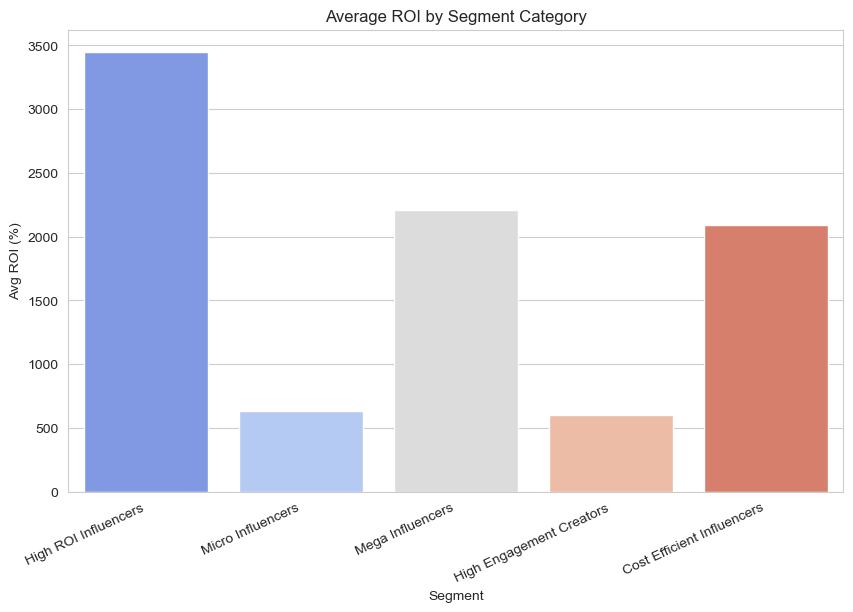

In [28]:
# ---------------------------------------------------
# Visualization 3: Segment comparison bar chart
# ---------------------------------------------------
plt.figure(figsize=(10, 6))
sns.barplot(data=segment_summary, x='Segment', y='Avg ROI (%)', hue='Segment',
            palette='coolwarm', legend=False)
plt.title('Average ROI by Segment Category')
plt.xticks(rotation=25, ha='right')
plt.savefig('p4_segment_roi_comparison.png', bbox_inches='tight', dpi=100)
plt.show()

In [29]:
# ---------------------------------------------------
# Save segmented data
# ---------------------------------------------------
inf_level.to_csv('influencer_segments.csv', index=False)
segment_summary.to_csv('segment_summary.csv', index=False)
print("Saved influencer_segments.csv and segment_summary.csv")

Saved influencer_segments.csv and segment_summary.csv
